In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score
)
import seaborn as sns
from sklearn.metrics import f1_score

In [2]:
ftr_pca = np.load('ftr_pca.npy')  # Training features
ftr_labels = np.load('ftr_labels.npy') # Training labels

ftest_pca  = np.load('ft_pca.npy')     # Testing features
ft_labels  = np.load('ft_labels.npy')  # Testing labels


print("Data loaded!")
print(f"Training features: {ftr_pca.shape}")
print(f"Training labels:   {ftr_labels.shape}")
print(f"Testing features:  {ftest_pca.shape}")
print(f"Testing labels:    {ft_labels.shape}")

Data loaded!
Training features: (4800000, 36)
Training labels:   (4800000,)
Testing features:  (8000000, 36)
Testing labels:    (8000000,)


In [3]:
# import os
# if os.path.exists('ftr_sim_runs.npy'):
#     sim_runs = np.load('ftr_sim_runs.npy')
#     print("SimRun loaded!", sim_runs.shape)
# else:
#     print("SimRun NOT saved!")
#     print("Need to go back to preprocessing!")

In [4]:
samples_per_run = 480
n_runs = 500

# For each fault: 500 runs × 480 samples
sim_runs = np.repeat(
    np.arange(1, 501),   # SimRun 1-500
    480 * 20             # 480 samples × 20 faults per run
)


print(f"SimRun shape: {sim_runs.shape}")
print(f"Unique runs:  {np.unique(sim_runs).shape}")
print(f"First 5:      {sim_runs[:5]}")
print(f"Last 5:       {sim_runs[-5:]}")

SimRun shape: (4800000,)
Unique runs:  (500,)
First 5:      [1 1 1 1 1]
Last 5:       [500 500 500 500 500]


In [5]:
train_size = 400 * 480 * 20

X_train = ftr_pca[:train_size]
y_train = ftr_labels[:train_size]

X_val   = ftr_pca[train_size:]
y_val   = ftr_labels[train_size:]

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape:   {X_val.shape}")

X_train shape: (3840000, 36)
X_val shape:   (960000, 36)


In [6]:
# Get sim_runs for training data only
sim_runs_train = sim_runs[:train_size]

# Randomly select 200 runs from 1-400
np.random.seed(42)
selected_runs = np.random.choice(
    np.arange(1, 401),
    size=200,
    replace=False
)

# Create mask for selected runs
sample_mask = np.isin(sim_runs_train, selected_runs)

# Extract sampled data
X_sample = X_train[sample_mask]
y_sample = y_train[sample_mask]

print(f"X_sample shape: {X_sample.shape}")
print(f"y_sample shape: {y_sample.shape}")

# Verify equal fault distribution
unique, counts = np.unique(y_sample, return_counts=True)
print("\nFault distribution in sample:")
for fault, count in zip(unique, counts):
    print(f"Fault {fault}: {count} rows | "
          f"Runs: {count//480}")

X_sample shape: (1920000, 36)
y_sample shape: (1920000,)

Fault distribution in sample:
Fault 1: 96000 rows | Runs: 200
Fault 2: 96000 rows | Runs: 200
Fault 3: 96000 rows | Runs: 200
Fault 4: 96000 rows | Runs: 200
Fault 5: 96000 rows | Runs: 200
Fault 6: 96000 rows | Runs: 200
Fault 7: 96000 rows | Runs: 200
Fault 8: 96000 rows | Runs: 200
Fault 9: 96000 rows | Runs: 200
Fault 10: 96000 rows | Runs: 200
Fault 11: 96000 rows | Runs: 200
Fault 12: 96000 rows | Runs: 200
Fault 13: 96000 rows | Runs: 200
Fault 14: 96000 rows | Runs: 200
Fault 15: 96000 rows | Runs: 200
Fault 16: 96000 rows | Runs: 200
Fault 17: 96000 rows | Runs: 200
Fault 18: 96000 rows | Runs: 200
Fault 19: 96000 rows | Runs: 200
Fault 20: 96000 rows | Runs: 200


In [7]:
# XGBoost needs labels starting from 0
# Your labels are 1-20, convert to 0-19!
y_sample_xgb = y_sample - 1  # XGBoost internally requires class labels starting from 0 — 
y_val_xgb    = y_val - 1     # if you pass labels 1-20 it either throws an error or creates an unnecessary empty class 0


# Train XGBoost
model = XGBClassifier(
    n_estimators    = 100,
    max_depth       = 6,
    learning_rate   = 0.1,
    n_jobs          = -1,      # Use all CPU cores
    random_state    = 42,
    eval_metric     = 'mlogloss',
    early_stopping_rounds = 10
)

model.fit(
    X_sample, y_sample_xgb,
    eval_set = [(X_val, y_val_xgb)],
    verbose  = 10  # Print every 10 rounds
)

print("Training complete!")

[0]	validation_0-mlogloss:2.56675
[10]	validation_0-mlogloss:1.63491
[20]	validation_0-mlogloss:1.34615
[30]	validation_0-mlogloss:1.20519
[40]	validation_0-mlogloss:1.12544
[50]	validation_0-mlogloss:1.07683
[60]	validation_0-mlogloss:1.04520
[70]	validation_0-mlogloss:1.02319
[80]	validation_0-mlogloss:1.00711
[90]	validation_0-mlogloss:0.99473
[99]	validation_0-mlogloss:0.98563
Training complete!


In [8]:
y_val_pred = model.predict(X_val)
y_val_pred_orig = y_val_pred + 1
y_val_orig = y_val_xgb + 1

macro_f1 = f1_score(
    y_val_orig,
    y_val_pred_orig,
    average = 'macro'
)

print(f"Macro F1 score: {macro_f1:.4f}")

f1_per_fault = f1_score(
    y_val_orig,
    y_val_pred_orig,
    average=None
)

res = []
print("\n Per fault F1 score:\n")
for fault, f1 in enumerate(f1_per_fault, 1):
    res.append({
        'Fault' : fault,
        'F1_score' : f1
    })

print(pd.DataFrame(res).set_index('Fault').sort_values(by = 'F1_score', ascending = False))

Macro F1 score: 0.6624

 Per fault F1 score:

       F1_score
Fault          
7      0.999917
6      0.990686
1      0.990309
2      0.988353
14     0.966496
8      0.935707
13     0.909089
12     0.868389
18     0.855780
4      0.833047
17     0.808078
11     0.578510
20     0.527044
19     0.512463
5      0.487360
10     0.382900
3      0.228775
9      0.170585
16     0.113954
15     0.100026


In [9]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Get predictions on validation set
y_val_pred = model.predict(X_val)

# Step 2: Convert back to original labels
y_val_pred_orig = y_val_pred + 1
y_val_orig      = y_val_xgb + 1

# Step 3: Confusion matrix
cm = confusion_matrix(y_val_orig, y_val_pred_orig)

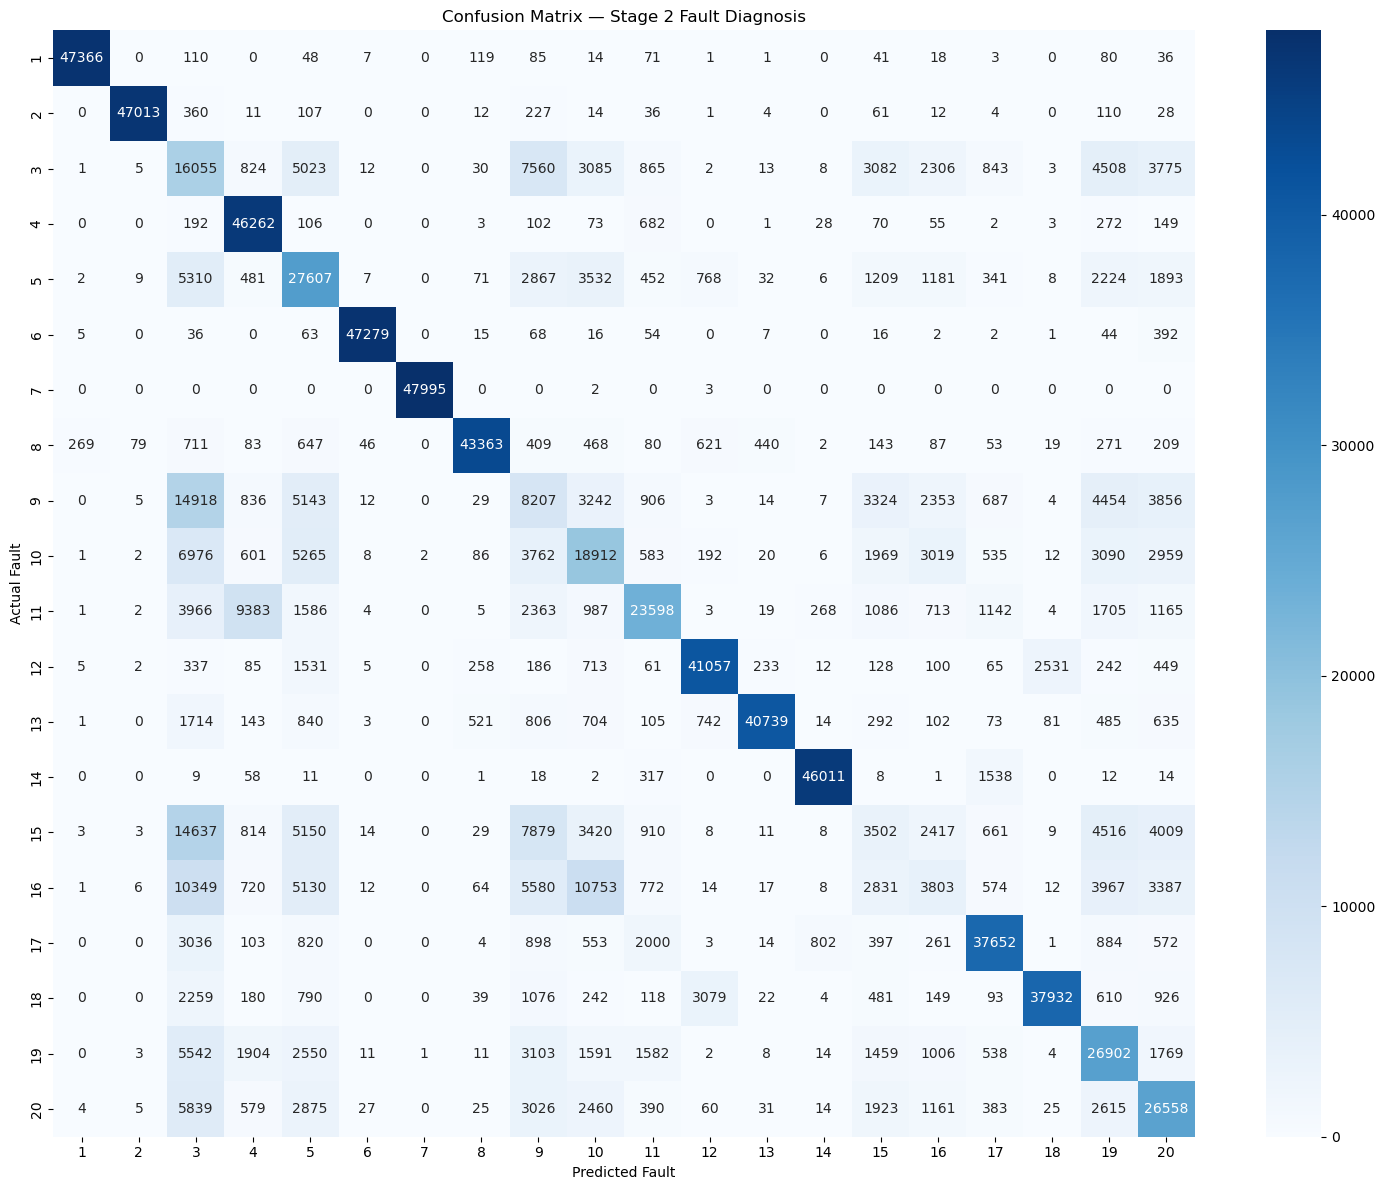

Overall Macro F1: 0.6624


In [10]:
# Plot confusion matrix
plt.figure(figsize=(15, 12))
sns.heatmap(
    cm,
    annot       = True,
    fmt         = 'd',
    cmap        = 'Blues',
    xticklabels = range(1, 21),
    yticklabels = range(1, 21)
)
plt.xlabel('Predicted Fault')
plt.ylabel('Actual Fault')
plt.title('Confusion Matrix — Stage 2 Fault Diagnosis')
plt.tight_layout()
plt.show()

# Also print overall Macro F1
from sklearn.metrics import f1_score
macro_f1 = f1_score(
    y_val_orig,
    y_val_pred_orig,
    average='macro'
)
print(f"Overall Macro F1: {macro_f1:.4f}")

In [11]:
len(y_val_pred)

960000

In [12]:
horizontal_sum = np.sum(cm, axis = 1)
vertical_sum = np.sum(cm, axis = 0)

output = pd.DataFrame(np.vstack((horizontal_sum, vertical_sum)), columns = ['Fault_1','Fault_2','Fault_3','Fault_4','Fault_5','Fault_6','Fault_7','Fault_8','Fault_9','Fault_10','Fault_11','Fault_12','Fault_13','Fault_14','Fault_15','Fault_16','Fault_17','Fault_18','Fault_19','Fault_20'], index = ['H', 'V'])

res = []

for i in range(1,21):
    ho = output.loc['H', f"Fault_{i}"]
    vi = output.loc['V', f"Fault_{i}"]

    ans = ""

    if ho > vi:
        ans = f"Model under-predict for Fault_{i}"
    elif ho < vi:
        ans = f"Model over-predicts for Fault_{i}"
    else:
        ans = f"Model predict accurately"

    TP = cm[i-1][i-1]
    FP = cm[:,i-1].sum() - TP
    FN = cm[i-1,:].sum() - TP

    precision = TP / (TP + FP)
    recall = TP / (TP + FN)

    F1_score = 2 * (precision * recall) / (precision + recall)
    #print(f"Fault_{i} has F1-score of {F1_score:.4f}\n")

    res.append({
        'Fault' : f"Fault_{i}",
        'Precision' : precision,
        'Recall' : recall,
        'F1-score' : F1_score,
        'Remark' : ans
    })

pd.DataFrame(res).sort_values("F1-score", ascending = True)        

,Fault,Precision,Recall,F1-score,Remark
14,Fault_15,0.159023,0.072958,0.100026,Model under-predict for Fault_15
15,Fault_16,0.202870,0.079229,0.113954,Model under-predict for Fault_16
8,Fault_9,0.170192,0.170979,0.170585,Model over-predicts for Fault_9
2,Fault_3,0.173838,0.334479,0.228775,Model over-predicts for Fault_3
9,Fault_10,0.372408,0.394000,0.382900,Model over-predicts for Fault_10
4,Fault_5,0.422824,0.575146,0.487360,Model over-predicts for Fault_5
18,Fault_19,0.472039,0.560458,0.512463,Model over-predicts for Fault_19
19,Fault_20,0.503173,0.553292,0.527044,Model over-predicts for Fault_20
10,Fault_11,0.702698,0.491625,0.578510,Model under-predict for Fault_11
16,Fault_17,0.833212,0.784417,0.808078,Model under-predict for Fault_17


### Observation:
- Model accurately and precisely predicts the following faults: Fault_17, Fault_4, Fault_18, Fault_12, Fault_13, Fault_8, Fault_14, Fault_2, Fault_1, Fault_6 and Fault_7.
- In fault_15, fault_16 and fault_9, Precision > Recall, however values of both are low. This means Model rarely predicts these faults. And when it does mostly wrong.
- For case of Fault_3, Model catches some faults and but also wrongly predicts some faults as Fault_3.
- And for case of Fault_4, Model catches all the faults but also misclassifies other faults as Fault_4.

In [13]:
# For each struggling fault
# find where misclassifications go
struggling_faults = [15, 16, 9, 3, 5]

for fault in struggling_faults:
    row = cm[fault-1]
    top_3 = np.argsort(row)[::-1][:3]
    
    print(f"\nActual Fault {fault} predicted as:")
    for pred in top_3:
        pct = row[pred]/row.sum()*100
        print(f"  Fault {pred+1}: "
              f"{row[pred]:,} samples "
              f"({pct:.1f}%)")


Actual Fault 15 predicted as:
  Fault 3: 14,637 samples (30.5%)
  Fault 9: 7,879 samples (16.4%)
  Fault 5: 5,150 samples (10.7%)

Actual Fault 16 predicted as:
  Fault 10: 10,753 samples (22.4%)
  Fault 3: 10,349 samples (21.6%)
  Fault 9: 5,580 samples (11.6%)

Actual Fault 9 predicted as:
  Fault 3: 14,918 samples (31.1%)
  Fault 9: 8,207 samples (17.1%)
  Fault 5: 5,143 samples (10.7%)

Actual Fault 3 predicted as:
  Fault 3: 16,055 samples (33.4%)
  Fault 9: 7,560 samples (15.8%)
  Fault 5: 5,023 samples (10.5%)

Actual Fault 5 predicted as:
  Fault 5: 27,607 samples (57.5%)
  Fault 3: 5,310 samples (11.1%)
  Fault 10: 3,532 samples (7.4%)


### Observation:
- Fault_3, Fault_9 and Fault_15 are wrongly predicted as Fault_3, Fault_9 and Fault_5. That means all have similar PCA pattern or behavior.
- Another model is required to distinguish between these faults as PCA cannot be able to distinguish between the similar pattern it develops for these faults.
- Stage 1(< 3% detection) and Stage 2 (F1 < 0.25) and confusion matrix analysis showing these faults specifically mistake each other. The root cause is their indistinguishable static PCA patterns, suggesting temporal LSTM modeling as the correct solution.

In [15]:
# In Stage 2 notebook — save XGBoost model!
joblib.dump(model, 'models/xgboost_stage2.pkl')
print("Model saved!")

Model saved!
